# Lab: Adversarial Defense via Robust Training

**Objective:** Compare a standard model to an adversarially trained robust model.

### Step 1: Setup & Data Loading

First, we import the necessary libraries and download the MNIST dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformation: Convert images to tensors
transform = transforms.Compose([transforms.ToTensor()])

train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

print(f"Setup complete. Training on: {device}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.68MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.85MB/s]

Setup complete. Training on: cpu


---

### Step 2: Define the Model Architecture

We will use a standard Convolutional Neural Network (CNN). This same "blueprint" will be used for both our vulnerable and robust models.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

---

### Step 3: Train the Baseline (Vulnerable) Model

This model is trained normally. It will be highly accurate on clean data but very fragile to adversarial noise.

In [ ]:
def train_standard(model, loader, optimizer, epochs=1):
    model.train()
    for epoch in range(epochs):
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = F.nll_loss(output, target)
            loss.backward()
            optimizer.step()
    print("Baseline model training complete.")



In [ ]:
std_model = SimpleCNN().to(device)
std_optimizer = optim.Adam(std_model.parameters(), lr=0.001)
train_standard(std_model, train_loader, std_optimizer)

Baseline model training complete.


---

### Step 4: Define the Attack (FGSM)

To train a robust model, we need to generate attacks *during* the training process. This function creates adversarial examples by moving pixels in the direction of the gradient.

In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image
    perturbed_image = image + epsilon * sign_data_grad
    # Adding clipping to maintain [0,1] range
    return torch.clamp(perturbed_image, 0, 1)

---

### Step 5: Train the Robust (Defended) Model

This is the **Adversarial Training** loop. For every batch, we generate a "hacked" version and tell the model to learn that it is still the same digit.

In [ ]:
def train_robust(model, loader, optimizer, epsilon=0.2, epochs=1):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)

            # 1. Generate adversarial examples
            data.requires_grad = True
            output = model(data)
            loss = F.nll_loss(output, target)
            model.zero_grad()
            loss.backward()

            # Use the gradients to create 'noisy' data
            adv_data = fgsm_attack(data, epsilon, data.grad)

            # 2. Train on BOTH clean and noisy data
            optimizer.zero_grad()
            combined_data = torch.cat([data, adv_data.detach()])
            combined_target = torch.cat([target, target])

            output_combined = model(combined_data)
            loss_robust = F.nll_loss(output_combined, combined_target)
            loss_robust.backward()
            optimizer.step()

        print(f"Epoch {epoch+1} robust training complete.")



In [ ]:
rob_model = SimpleCNN().to(device)
rob_optimizer = optim.Adam(rob_model.parameters(), lr=0.001)
train_robust(rob_model, train_loader, rob_optimizer)

Epoch 1 robust training complete.


---

### Step 6: Evaluation & Comparative Analysis

Now we put both models to the test. We measure how they perform on normal images vs. adversarial images (at $\epsilon = 0.2$).

In [ ]:
def evaluate(model, loader, epsilon):
    model.eval()
    clean_correct = 0
    adv_correct = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)

        # Clean test
        output = model(data)
        clean_correct += (output.argmax(1) == target).sum().item()

        # Adversarial test
        data.requires_grad = True
        output = model(data)
        loss = F.nll_loss(output, target)
        model.zero_grad()
        loss.backward()

        adv_data = fgsm_attack(data, epsilon, data.grad)
        adv_output = model(adv_data)
        adv_correct += (adv_output.argmax(1) == target).sum().item()

    return clean_correct / len(loader.dataset), adv_correct / len(loader.dataset)



In [ ]:
# Results
eps_test = 0.25
std_clean, std_adv = evaluate(std_model, test_loader, eps_test)
rob_clean, rob_adv = evaluate(rob_model, test_loader, eps_test)

print(f"\nStandard Model Accuracy: Clean: {std_clean:.1%}, Adv: {std_adv:.1%}")
print(f"Robust Model Accuracy:   Clean: {rob_clean:.1%}, Adv: {rob_adv:.1%}")


Standard Model Accuracy: Clean: 98.4%, Adv: 20.5%
Robust Model Accuracy:   Clean: 98.5%, Adv: 86.5%


---

### Step 7: Visualizing the Defense

Finally, let's see an example of an image that fools the **Standard Model** but is correctly identified by the **Robust Model**.

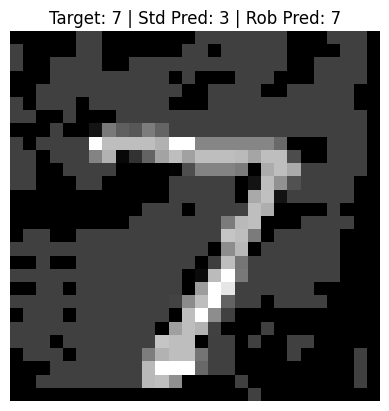

In [ ]:
# Pull a single sample
data, target = next(iter(test_loader))
data, target = data[0:1].to(device), target[0:1].to(device)
data.requires_grad = True

# Attack
output = std_model(data)
loss = F.nll_loss(output, target)
std_model.zero_grad()
loss.backward()
adv_sample = fgsm_attack(data, eps_test, data.grad)

# Predictions
std_pred = std_model(adv_sample).argmax(1).item()
rob_pred = rob_model(adv_sample).argmax(1).item()

# Plot
plt.imshow(adv_sample.detach().cpu().squeeze(), cmap='gray')
plt.title(f"Target: {target.item()} | Std Pred: {std_pred} | Rob Pred: {rob_pred}")
plt.axis('off')
plt.show()